# Assigning new times to each of the GRB events


The total valid time-range is 00:00:00 UTC January 1st, 2028, until 00:00:00 December 31st, 2034.

In [1]:
from pathlib import Path
from datetime import datetime
import random

from matplotlib import pyplot as plt
import pandas as pd

In [12]:
catalog = Path('/Users/jarred/Downloads/TeV Catalog O5')

list_of_files = list(catalog.glob('*.fits'))

print(f"Found {len(list_of_files)} files")


Found 2307 files


In [13]:
int(list_of_files[0].stem.split('_')[1])

def get_event_id(file_name):
    return int(file_name.stem.split('_')[1])

def get_random_event_time(start_time, end_time):
    return datetime.fromtimestamp(random.uniform(start_time.timestamp(), end_time.timestamp()))


In [14]:
list_of_files[0].name

'catO5_525.fits'

## Assign two times to each of the events

In [15]:
start_time = datetime(2028, 1, 1, 0, 0, 0)
end_time = datetime(2034, 12, 31, 0, 0, 0)

# Set seed for reproducibility
random.seed(43928)

new_times = {}
event_id = 0

times_only = {}

for file in sorted(list_of_files, key=lambda x: get_event_id(x)):
    file_id = get_event_id(file)
    time_1 = get_random_event_time(start_time, end_time)
    time_2 = get_random_event_time(start_time, end_time)

    new_times[event_id] = {
        "event_id": event_id,
        "file_id": file_id,
        "file_name": file.name,
        "timestamp": time_1,
    }

    event_id += 1
    
    new_times[event_id] = {
        "event_id": event_id,
        "file_id": file_id,
        "file_name": file.name,
        "timestamp": time_2,
    }
    
    event_id += 1
    
    times_only[file_id] = {
        "file_id": file_id,
        "file_name": file.name,
        "timestamp_1": time_1,
        "timestamp_2": time_2
    }
    
df = pd.DataFrame.from_dict(new_times, orient='index')
df.set_index('event_id', inplace=True)
df.sort_index(inplace=True)

times_df = pd.DataFrame.from_dict(times_only, orient='index')
times_df.set_index('file_id', inplace=True)
times_df.sort_index(inplace=True)


In [17]:
### Assign superevent ids

events = df.sort_values(by="timestamp")
all_timestamps = events.timestamp.values

# convert to datetime
all_timestamps = pd.to_datetime(all_timestamps).to_series()

# get the unique dates
dates = all_timestamps.dt.date

# do a lookup table by date {date: [timestamps]}
lookup = {date: all_timestamps[all_timestamps.dt.date == date].values for date in dates}

# assign superevent ids: GWYYMMDDa, b, c for each date
superevent_ids = []
for date, timestamps in lookup.items():
    for i, timestamp in enumerate(timestamps):
        superevent_ids.append(f"GW{date.strftime('%y%m%d')}{chr(97 + i)}")

# add to events
events["superevent_id"] = superevent_ids


In [21]:
events.to_csv('ctao_event_times.csv')
times_df.to_csv('ctao_event_times_only.csv')

### Check the distribution against the expected Poisson

In [127]:
# check if there are any events with the exact same day
# Create full date range to include days with 0 events
all_dates = pd.date_range(start=start_time.date(), end=end_time.date(), freq='D')
total_days_in_range = len(all_dates)

# Count events per day (including days with 0 events)
events_per_day = df.groupby(df['timestamp'].dt.date).size()
events_per_day_full = pd.Series(0, index=pd.Index([d.date() for d in all_dates]))
events_per_day_full.update(events_per_day)
events_per_day_full = events_per_day_full.astype(int)

print("Events per day distribution:")
print(events_per_day_full.value_counts().sort_index())
print(f"\nTotal days in range: {total_days_in_range}")
print(f"Days with events: {len(events_per_day)}")
print(f"Days with 0 events: {(events_per_day_full == 0).sum()}")
print(f"Total timestamps: {len(df)}")
print(f"Actual average events/day: {len(df) / total_days_in_range:.2f}")
print(f"Expected average (your calc): 2.2 events/day")
print(f"Expected average (correct calc): {len(df) / total_days_in_range:.2f} events/day")

# Check if distribution follows Poisson (expected for random events)
import numpy as np
from scipy import stats

lambda_expected = len(df) / total_days_in_range
print(f"\nPoisson parameter λ (expected): {lambda_expected:.2f}")

# Compare actual distribution to Poisson
observed_counts = events_per_day_full.value_counts().sort_index()
print("\nComparing to Poisson distribution:")
max_events = int(events_per_day_full.max())
for k in range(max_events + 1):
    poisson_prob = stats.poisson.pmf(k, lambda_expected) * total_days_in_range
    actual_count = observed_counts.get(k, 0)
    diff = actual_count - poisson_prob
    print(f"Days with {k} events: {actual_count:4d} (Poisson expects: {poisson_prob:6.1f}, diff: {diff:+.1f})")


Events per day distribution:
0     419
1     760
2     690
3     411
4     184
5      67
6      17
7       6
8       2
10      1
Name: count, dtype: int64

Total days in range: 2557
Days with events: 2138
Days with 0 events: 419
Total timestamps: 4614
Actual average events/day: 1.80
Expected average (your calc): 2.2 events/day
Expected average (correct calc): 1.80 events/day

Poisson parameter λ (expected): 1.80

Comparing to Poisson distribution:
Days with 0 events:  419 (Poisson expects:  420.8, diff: -1.8)
Days with 1 events:  760 (Poisson expects:  759.3, diff: +0.7)
Days with 2 events:  690 (Poisson expects:  685.1, diff: +4.9)
Days with 3 events:  411 (Poisson expects:  412.1, diff: -1.1)
Days with 4 events:  184 (Poisson expects:  185.9, diff: -1.9)
Days with 5 events:   67 (Poisson expects:   67.1, diff: -0.1)
Days with 6 events:   17 (Poisson expects:   20.2, diff: -3.2)
Days with 7 events:    6 (Poisson expects:    5.2, diff: +0.8)
Days with 8 events:    2 (Poisson expects:  


Chi-square test against Poisson distribution:
Chi-square statistic: 2.34
P-value: 0.9687
✓ Distribution appears consistent with Poisson (random) distribution


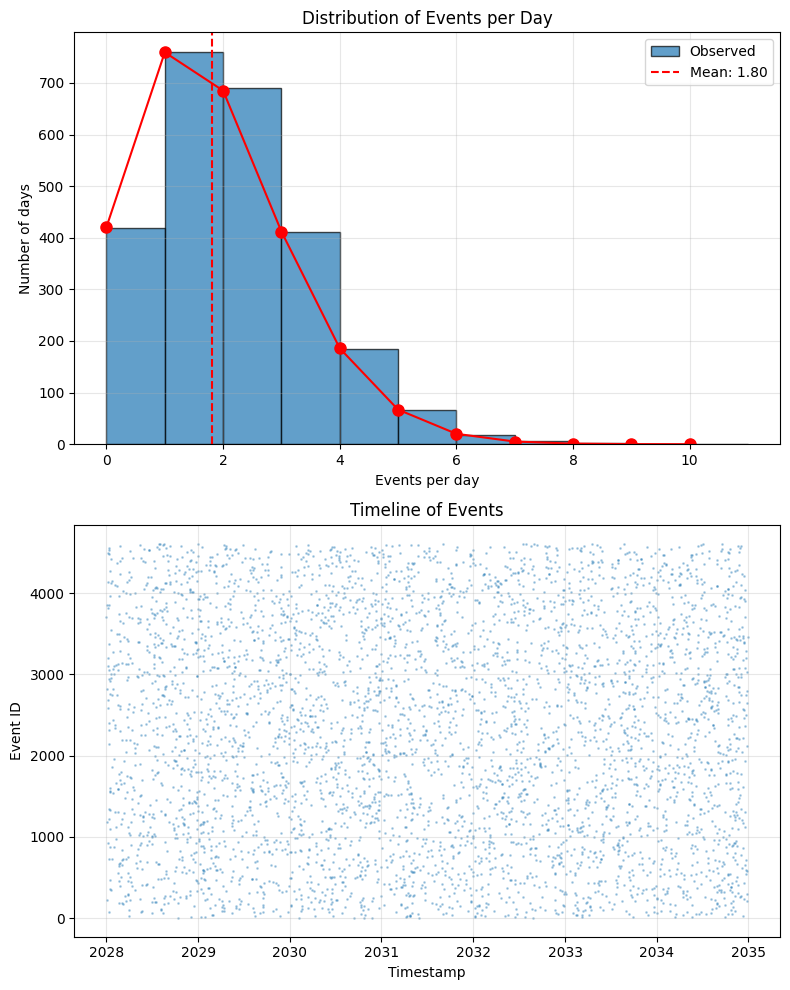

In [128]:
# Visualize the distribution of events per day
fig, axes = plt.subplots(2, 1, figsize=(8, 10))

# Histogram of events per day (using full range including 0 events)
axes[0].hist(events_per_day_full, bins=range(int(events_per_day_full.max()) + 2), 
             alpha=0.7, edgecolor='black', label='Observed')
axes[0].axvline(events_per_day_full.mean(), color='red', linestyle='--', 
                label=f'Mean: {events_per_day_full.mean():.2f}')
axes[0].set_xlabel('Events per day')
axes[0].set_ylabel('Number of days')
axes[0].set_title('Distribution of Events per Day')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Overlay Poisson distribution
x = np.arange(0, int(events_per_day_full.max()) + 1)
poisson_vals = stats.poisson.pmf(x, lambda_expected) * total_days_in_range
axes[0].plot(x, poisson_vals, 'ro-', label='Poisson (expected)', markersize=8)

# Timeline view - events over time
axes[1].scatter(df['timestamp'], df.index, s=1, alpha=0.3)
axes[1].set_xlabel('Timestamp')
axes[1].set_ylabel('Event ID')
axes[1].set_title('Timeline of Events')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()

# Statistical test: Chi-square test against Poisson
print("\nChi-square test against Poisson distribution:")
observed_freq = events_per_day_full.value_counts().sort_index()
expected_freq = {}
max_k = int(events_per_day_full.max())
for k in range(max_k + 1):
    expected_freq[k] = stats.poisson.pmf(k, lambda_expected) * total_days_in_range

# Prepare arrays for chi-square test (combine bins with expected < 5 for validity)
obs_array = []
exp_array = []
combined_obs = 0
combined_exp = 0

for k in range(max_k + 1):
    obs_val = observed_freq.get(k, 0)
    exp_val = expected_freq.get(k, 0)
    
    if exp_val >= 5:
        # Flush any combined bins first
        if combined_obs > 0 or combined_exp > 0:
            obs_array.append(combined_obs)
            exp_array.append(combined_exp)
            combined_obs = 0
            combined_exp = 0
        # Add this bin individually
        obs_array.append(obs_val)
        exp_array.append(exp_val)
    else:
        # Combine small bins
        combined_obs += obs_val
        combined_exp += exp_val

# Add any remaining combined bins
if combined_obs > 0 or combined_exp > 0:
    obs_array.append(combined_obs)
    exp_array.append(combined_exp)

# Normalize expected to match observed sum (fixes floating point precision issues)
obs_sum = sum(obs_array)
exp_sum = sum(exp_array)
if abs(obs_sum - exp_sum) > 1e-6:
    exp_array = [e * obs_sum / exp_sum for e in exp_array]

chi2_stat, p_value = stats.chisquare(obs_array, exp_array)
print(f"Chi-square statistic: {chi2_stat:.2f}")
print(f"P-value: {p_value:.4f}")
if p_value > 0.05:
    print("✓ Distribution appears consistent with Poisson (random) distribution")
else:
    print("⚠ Distribution may deviate from Poisson (random) distribution")
    print("   (This could indicate clustering or non-randomness)")
    
plt.show()